In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. Load and clean the data

In [4]:
df = pd.read_csv('Return_Data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

In [6]:
# 分析区间 2011–2022
df = df.loc['2011-01-01':'2022-12-31']
core_assets = ['U.S. Bonds', 'U.S.Total Equities', 'Gold', 'BTC']
data = df[core_assets].dropna(how='any')
print(f"sample time range: {data.index.min().date()} → {data.index.max().date()} | {len(data)} months\n")

def ann_stats(monthly):
    mu = monthly.mean() * 12
    cov = monthly.cov() * 12
    return mu, cov

mu_full, cov_full = ann_stats(data)
print("Annualized Expected Returns:")
print(mu_full.round(4))
print("\nAnnualized Volatilities:")
print(np.sqrt(np.diag(cov_full)).round(4))
print("\nCorrelation Matrix:")
print(data.corr().round(3))

sample time range: 2011-04-30 → 2022-12-31 | 141 months

Annualized Expected Returns:
U.S. Bonds            0.0193
U.S.Total Equities    0.1173
Gold                  0.0329
BTC                   1.6977
dtype: float64

Annualized Volatilities:
[0.0393 0.1509 0.1631 1.8833]

Correlation Matrix:
                    U.S. Bonds  U.S.Total Equities   Gold    BTC
U.S. Bonds               1.000               0.196  0.338  0.093
U.S.Total Equities       0.196               1.000  0.091  0.163
Gold                     0.338               0.091  1.000 -0.022
BTC                      0.093               0.163 -0.022  1.000


## 2. Optimization Helper Functions

In [7]:
def port_ret(w, mu):
    return float(w @ mu)

def port_vol(w, cov):
    return float(np.sqrt(w @ cov @ w))

def neg_sharpe(w, mu, cov, rf=0.02):
    r = port_ret(w, mu)
    v = port_vol(w, cov)
    return -(r - rf) / v if v > 1e-8 else 0

def max_sharpe(mu, cov, rf=0.02):
    n = len(mu)
    cons = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    bounds = [(0.0, 1.0)] * n
    res = minimize(neg_sharpe, np.ones(n)/n, args=(mu, cov, rf),
                   method='SLSQP', bounds=bounds, constraints=cons, tol=1e-12)
    return res.x if res.success else np.ones(n)/n

def min_vol(mu, cov):
    n = len(mu)
    cons = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    bounds = [(0.0, 1.0)] * n
    res = minimize(lambda w: port_vol(w, cov), np.ones(n)/n,
                   method='SLSQP', bounds=bounds, constraints=cons, tol=1e-12)
    return res.x if res.success else np.ones(n)/n

def efficient_frontier(mu, cov, n_points=50):
    w_mv = min_vol(mu, cov)
    w_ms = max_sharpe(mu, cov)
    r_min = port_ret(w_mv, mu)
    r_max = max(port_ret(w_ms, mu) * 1.25, r_min + 0.05)
    targets = np.linspace(r_min, r_max, n_points)
    vols, rets = [], []
    n = len(mu)
    bounds = [(0.0, 1.0)] * n
    for tr in targets:
        cons = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'eq', 'fun': lambda w, t=tr: port_ret(w, mu) - t}
        ]
        res = minimize(lambda w: port_vol(w, cov), np.ones(n)/n,
                       method='SLSQP', bounds=bounds, constraints=cons, tol=1e-10)
        if res.success:
            vols.append(port_vol(res.x, cov))
            rets.append(port_ret(res.x, mu))
    return np.array(vols), np.array(rets)

## 不知道有没有用，反正我先写上了
def calc_metrics(w, mu, cov, monthly_rets, rf=0.02):
    r = port_ret(w, mu)
    v = port_vol(w, cov)
    sharpe = (r - rf) / v if v > 0 else np.nan
    port_m = monthly_rets @ w
    cum = (1 + port_m).cumprod()
    peak = cum.cummax()
    dd = (cum - peak) / peak
    maxdd = dd.min()
    calmar = r / abs(maxdd) if maxdd < 0 else np.nan
    return {'Return': r, 'Vol': v, 'Sharpe': sharpe, 'MaxDD': maxdd, 'Calmar': calmar}

## 3. Four-Scenario Optimization

- No Gold, No BTC
- Gold only
- BTC only
- Gold + BTC

In [8]:
scenarios = {
    'No Gold No BTC': ['U.S. Bonds', 'U.S.Total Equities'],
    'Gold only':      ['U.S. Bonds', 'U.S.Total Equities', 'Gold'],
    'BTC only':       ['U.S. Bonds', 'U.S.Total Equities', 'BTC'],
    'Gold + BTC':     ['U.S. Bonds', 'U.S.Total Equities', 'Gold', 'BTC'],
}

frontier_data = {}
opt_results = {}

print("\n" + "="*70)
print("Four-scenario Max-Sharpe / Min-Vol result")
print("="*70)

for name, assets in scenarios.items():
    sub = data[assets]
    mu, cov = ann_stats(sub)
    w_ms = max_sharpe(mu, cov)
    w_mv = min_vol(mu, cov)
    vols, rets = efficient_frontier(mu, cov)
    
    metrics_ms = calc_metrics(w_ms, mu, cov, sub)
    metrics_mv = calc_metrics(w_mv, mu, cov, sub)
    
    frontier_data[name] = {'vols': vols, 'rets': rets}
    opt_results[name] = {
        'mu': mu, 'cov': cov, 'assets': assets,
        'w_ms': w_ms, 'w_mv': w_mv,
        'ms': metrics_ms, 'mv': metrics_mv
    }
    
    print(f"\n----- {name} -----")
    print("Max-Sharpe Weights:")
    for a, w in zip(assets, w_ms):
        print(f"  {a:25s}: {w:6.1%}")
    print(f"  → Return {metrics_ms['Return']:.2%}  Vol {metrics_ms['Vol']:.2%}  "
          f"Sharpe {metrics_ms['Sharpe']:.2f}  MaxDD {metrics_ms['MaxDD']:.2%}")


Four-scenario Max-Sharpe / Min-Vol result

----- No Gold No BTC -----
Max-Sharpe Weights:
  U.S. Bonds               :   0.0%
  U.S.Total Equities       : 100.0%
  → Return 11.73%  Vol 15.09%  Sharpe 0.64  MaxDD -24.86%

----- Gold only -----
Max-Sharpe Weights:
  U.S. Bonds               :   0.0%
  U.S.Total Equities       :  97.1%
  Gold                     :   2.9%
  → Return 11.49%  Vol 14.71%  Sharpe 0.65  MaxDD -24.36%

----- BTC only -----
Max-Sharpe Weights:
  U.S. Bonds               :   0.0%
  U.S.Total Equities       :  88.8%
  BTC                      :  11.2%
  → Return 29.42%  Vol 26.76%  Sharpe 1.02  MaxDD -29.16%

----- Gold + BTC -----
Max-Sharpe Weights:
  U.S. Bonds               :   0.0%
  U.S.Total Equities       :  82.0%
  Gold                     :   7.5%
  BTC                      :  10.5%
  → Return 27.63%  Vol 24.98%  Sharpe 1.03  MaxDD -27.51%


## 4. Replacement Experiment

1. 所有黄金权重都换成BTC
2. 等波动率替换

In [9]:
print("\n" + "="*70)
print("Replacement Experiment: Can BTC Replace Gold?")
print("="*70)

base = opt_results['Gold only']
base_assets = base['assets']
base_w = base['w_ms']
base_metrics = base['ms']

print("\n[Baseline] Gold-only Max-Sharpe:")
for a, w in zip(base_assets, base_w):
    print(f"  {a:25s}: {w:6.1%}")
print(f"  → Return {base_metrics['Return']:.2%}  Vol {base_metrics['Vol']:.2%}  "
      f"Sharpe {base_metrics['Sharpe']:.2f}  MaxDD {base_metrics['MaxDD']:.2%}")

# Replace 1: Allocate all Gold weight to BTC
w_replace1 = np.zeros(4)
w_replace1[0] = base_w[0]          # Bonds
w_replace1[1] = base_w[1]          # Equities
w_replace1[3] = base_w[2]          # Gold → BTC
# Gold weight = 0

# Replace 2: Volatility-scaled replacement
gold_vol = np.sqrt(base['cov'].loc['Gold', 'Gold'])
btc_vol  = np.sqrt(cov_full.loc['BTC', 'BTC'])
scale = gold_vol / btc_vol
w_btc_scaled = base_w[2] * scale
remaining = 1 - w_btc_scaled
non_gold_w = base_w[0] + base_w[1]
if non_gold_w > 0:
    w_replace2 = np.array([
        base_w[0] / non_gold_w * remaining,
        base_w[1] / non_gold_w * remaining,
        0.0,
        w_btc_scaled
    ])
else:
    w_replace2 = np.array([0., 0., 0., 1.])

mu4, cov4 = ann_stats(data)
m_base = calc_metrics(np.array([base_w[0], base_w[1], base_w[2], 0.]), mu4, cov4, data)
m_rep1 = calc_metrics(w_replace1, mu4, cov4, data)
m_rep2 = calc_metrics(w_replace2, mu4, cov4, data)

print("\n[Replace1] 100% of Gold weight → BTC:")
print(f"  Weights: Bonds {w_replace1[0]:.1%}  Equities {w_replace1[1]:.1%}  Gold 0%  BTC {w_replace1[3]:.1%}")
print(f"  → Return {m_rep1['Return']:.2%}  Vol {m_rep1['Vol']:.2%}  "
      f"Sharpe {m_rep1['Sharpe']:.2f}  MaxDD {m_rep1['MaxDD']:.2%}")

print("\n[Replace2] Volatility-scaled replacement:")
print(f"  Weights: Bonds {w_replace2[0]:.1%}  Equities {w_replace2[1]:.1%}  Gold 0%  BTC {w_replace2[3]:.1%}")
print(f"  → Return {m_rep2['Return']:.2%}  Vol {m_rep2['Vol']:.2%}  "
      f"Sharpe {m_rep2['Sharpe']:.2f}  MaxDD {m_rep2['MaxDD']:.2%}")

comp = pd.DataFrame({
    'Baseline (Gold only)': m_base,
    'Replace1 (100%→BTC)': m_rep1,
    'Replace2 (Vol-scaled)': m_rep2
}).T
print("\n=== Replacement Comparison Table ===")
print(comp.round(4))


Replacement Experiment: Can BTC Replace Gold?

[Baseline] Gold-only Max-Sharpe:
  U.S. Bonds               :   0.0%
  U.S.Total Equities       :  97.1%
  Gold                     :   2.9%
  → Return 11.49%  Vol 14.71%  Sharpe 0.65  MaxDD -24.36%

[Replace1] 100% of Gold weight → BTC:
  Weights: Bonds 0.0%  Equities 97.1%  Gold 0%  BTC 2.9%
  → Return 16.32%  Vol 16.45%  Sharpe 0.87  MaxDD -25.83%

[Replace2] Volatility-scaled replacement:
  Weights: Bonds 0.0%  Equities 99.7%  Gold 0%  BTC 0.3%
  → Return 12.13%  Vol 15.14%  Sharpe 0.67  MaxDD -24.95%

=== Replacement Comparison Table ===
                       Return     Vol  Sharpe   MaxDD  Calmar
Baseline (Gold only)   0.1149  0.1471  0.6453 -0.2436  0.4717
Replace1 (100%→BTC)    0.1632  0.1645  0.8701 -0.2583  0.6317
Replace2 (Vol-scaled)  0.1213  0.1514  0.6692 -0.2495  0.4863


## 5. Rolling Correlation + Crisis Performance

In [10]:
print("\n" + "="*70)
print("36-Month Rolling Correlation & Crisis-Month Performance")
print("="*70)

gold_eq, btc_eq, dates = [], [], []
for dt in data.index[35:]:
    c = data.loc[:dt, ['U.S.Total Equities', 'Gold', 'BTC']].tail(36).corr()
    gold_eq.append(c.loc['Gold', 'U.S.Total Equities'])
    btc_eq.append(c.loc['BTC', 'U.S.Total Equities'])
    dates.append(dt)

roll_df = pd.DataFrame({'Gold-Equity': gold_eq, 'BTC-Equity': btc_eq}, index=dates)
print(roll_df.describe().round(3))
print(f"\nAverage Gold-Equity Correlation: {roll_df['Gold-Equity'].mean():.3f}")
print(f"Average BTC-Equity  Correlation: {roll_df['BTC-Equity'].mean():.3f}")

crisis = data[data['U.S.Total Equities'] < -0.05]
print(f"\nNumber of Crisis Months (Equity < -5%): {len(crisis)}")
if len(crisis) > 0:
    print("Average Returns in Crisis Months:")
    print(crisis[['U.S.Total Equities', 'Gold', 'BTC']].mean().round(4))
    print("\nCorrelation in Crisis Months:")
    print(crisis[['U.S.Total Equities', 'Gold', 'BTC']].corr().round(3))


36-Month Rolling Correlation & Crisis-Month Performance
       Gold-Equity  BTC-Equity
count      106.000     106.000
mean         0.028       0.215
std          0.140       0.159
min         -0.232      -0.079
25%         -0.095       0.144
50%          0.019       0.190
75%          0.119       0.301
max          0.447       0.618

Average Gold-Equity Correlation: 0.028
Average BTC-Equity  Correlation: 0.215

Number of Crisis Months (Equity < -5%): 15
Average Returns in Crisis Months:
U.S.Total Equities   -0.0768
Gold                  0.0072
BTC                  -0.1106
dtype: float64

Correlation in Crisis Months:
                    U.S.Total Equities   Gold    BTC
U.S.Total Equities               1.000  0.216  0.203
Gold                             0.216  1.000  0.008
BTC                              0.203  0.008  1.000


## 6. Plotting

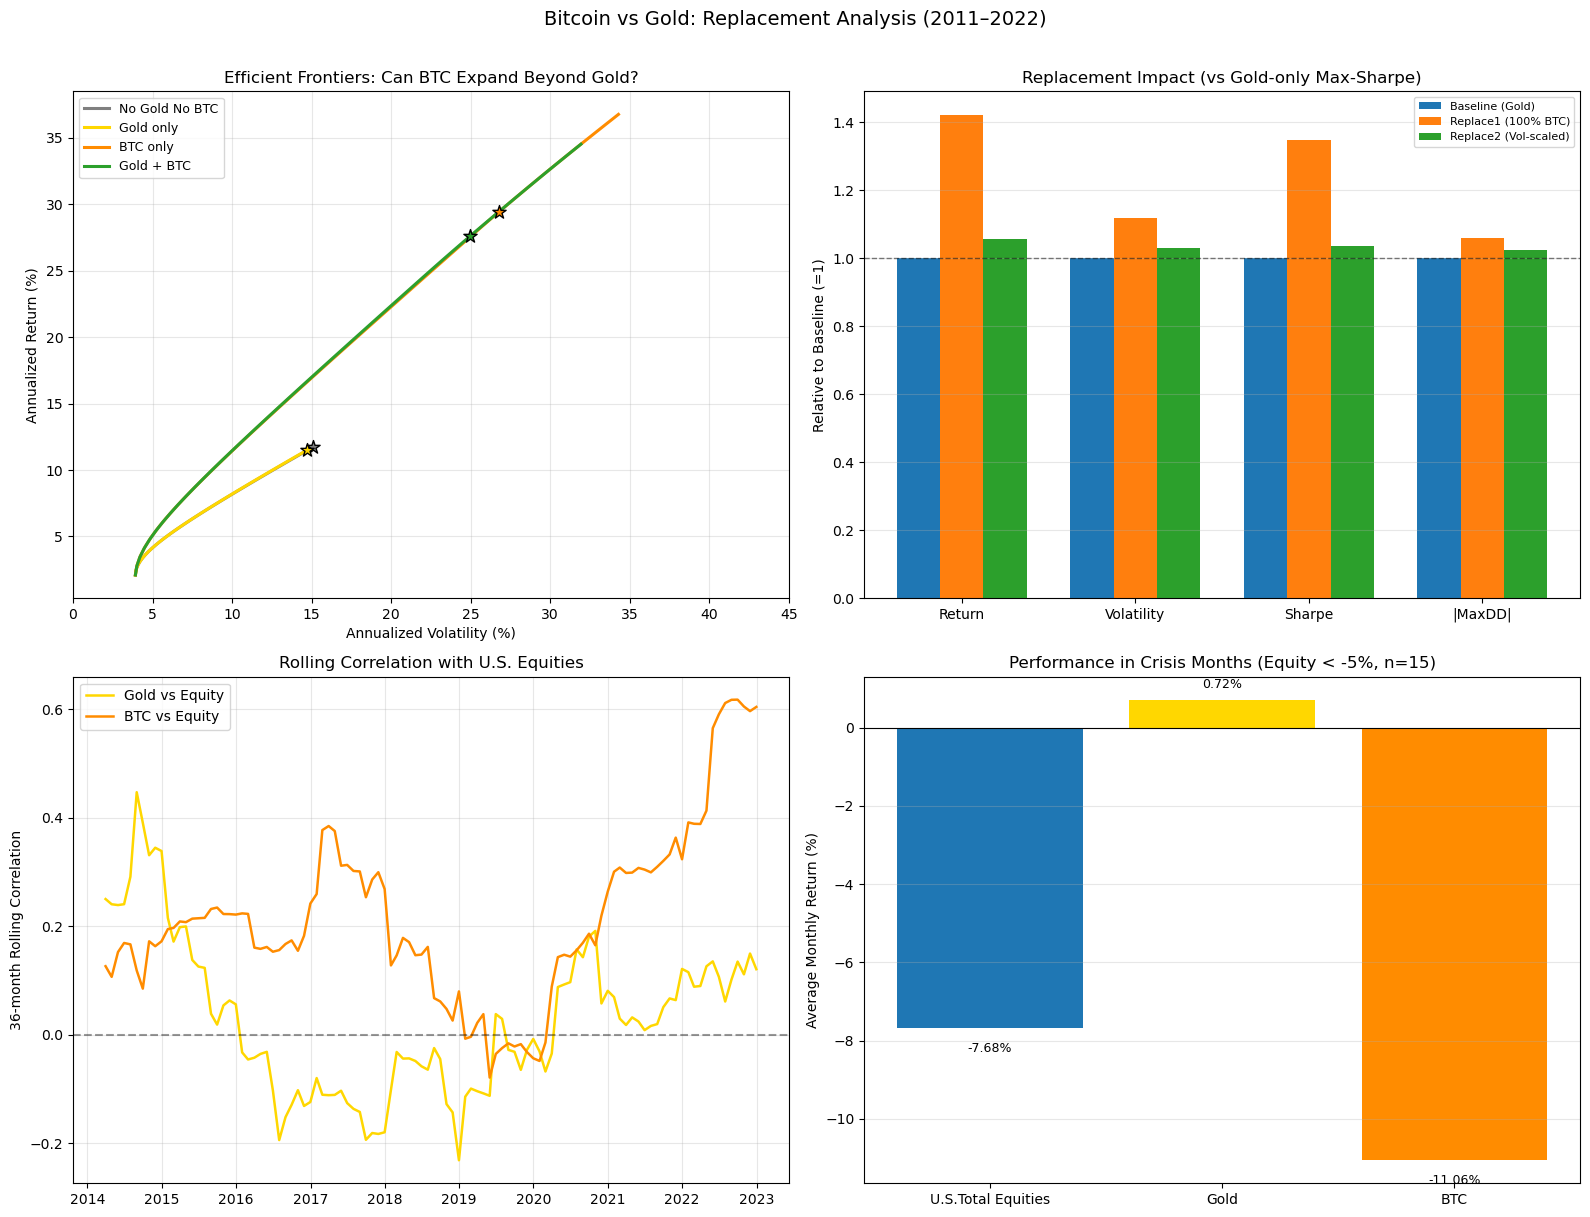

In [12]:
fig = plt.figure(figsize=(16, 12))

# Plot 1: Four Efficient Frontiers
ax1 = fig.add_subplot(2, 2, 1)
colors = {
    'No Gold No BTC': '#7f7f7f',
    'Gold only': '#FFD700',
    'BTC only': '#FF8C00',
    'Gold + BTC': '#2ca02c'
}
for name, fd in frontier_data.items():
    ax1.plot(fd['vols']*100, fd['rets']*100, lw=2.2, color=colors[name], label=name)
    ms = opt_results[name]['ms']
    ax1.scatter(ms['Vol']*100, ms['Return']*100, s=100, c=colors[name],
                edgecolors='k', zorder=5, marker='*')
ax1.set_xlabel('Annualized Volatility (%)')
ax1.set_ylabel('Annualized Return (%)')
ax1.set_title('Efficient Frontiers: Can BTC Expand Beyond Gold?')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 45)

# Plot 2: Replacement Impact (relative to baseline)
ax2 = fig.add_subplot(2, 2, 2)
raw = pd.DataFrame({
    'Baseline (Gold)': [m_base['Return'], m_base['Vol'], m_base['Sharpe'], abs(m_base['MaxDD'])],
    'Replace1 (100% BTC)': [m_rep1['Return'], m_rep1['Vol'], m_rep1['Sharpe'], abs(m_rep1['MaxDD'])],
    'Replace2 (Vol-scaled)': [m_rep2['Return'], m_rep2['Vol'], m_rep2['Sharpe'], abs(m_rep2['MaxDD'])]
})
norm = raw.div(raw['Baseline (Gold)'], axis=0)
x = np.arange(4)
width = 0.25
for i, col in enumerate(norm.columns):
    ax2.bar(x + i*width, norm[col], width, label=col)
ax2.axhline(1, color='k', ls='--', lw=1, alpha=0.5)
ax2.set_xticks(x + width)
ax2.set_xticklabels(['Return', 'Volatility', 'Sharpe', '|MaxDD|'])
ax2.set_ylabel('Relative to Baseline (=1)')
ax2.set_title('Replacement Impact (vs Gold-only Max-Sharpe)')
ax2.legend(fontsize=8)
ax2.grid(True, axis='y', alpha=0.3)

# Plot 3: Rolling Correlation
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(roll_df.index, roll_df['Gold-Equity'], label='Gold vs Equity', color='#FFD700', lw=1.8)
ax3.plot(roll_df.index, roll_df['BTC-Equity'], label='BTC vs Equity', color='#FF8C00', lw=1.8)
ax3.axhline(0, color='k', ls='--', alpha=0.4)
ax3.set_ylabel('36-month Rolling Correlation')
ax3.set_title('Rolling Correlation with U.S. Equities')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Crisis-Month Performance
ax4 = fig.add_subplot(2, 2, 4)
if len(crisis) > 0:
    crisis_mean = crisis[['U.S.Total Equities', 'Gold', 'BTC']].mean() * 100
    bars = ax4.bar(crisis_mean.index, crisis_mean.values,
                   color=['#1f77b4', '#FFD700', '#FF8C00'])
    ax4.axhline(0, color='k', lw=0.8)
    ax4.set_ylabel('Average Monthly Return (%)')
    ax4.set_title(f'Performance in Crisis Months (Equity < -5%, n={len(crisis)})')
    for bar, val in zip(bars, crisis_mean.values):
        ax4.text(bar.get_x() + bar.get_width()/2, val + (0.3 if val >= 0 else -0.6),
                 f'{val:.2f}%', ha='center', fontsize=9)
ax4.grid(True, axis='y', alpha=0.3)

plt.suptitle('Bitcoin vs Gold: Replacement Analysis (2011–2022)', fontsize=14, y=1.01)
plt.tight_layout()
# plt.savefig('btc_vs_gold_replacement_analysis.png', dpi=150, bbox_inches='tight')
# print("\nFigure saved: btc_vs_gold_replacement_analysis.png")

# Save tables 
# comp.to_csv('replacement_comparison.csv')
# roll_df.to_csv('rolling_corr_equity.csv')
# print("Tables saved: replacement_comparison.csv , rolling_corr_equity.csv")
# print("\nAll done!")